# F4 – Bestimmung von Federkonstanten

**Physikalisches Grundpraktikum – HU Berlin**

Bestimmung der Federkonstante einer Schraubenfeder mit drei Methoden:

1. **Statische Messung** – Lineare Abhängigkeit $x = x(m)$: Steigungsdreieck und lineare Regression
2. **Dynamische Messung** – Federkonstante aus der Periodendauer der Schwingung
3. **Geometrische Berechnung** – Federkonstante aus Torsionsmodul und Federgeometrie (Gl. 6)
4. **Systematische Abweichungen** – Abschätzung der Obergrenzen bei Aufgaben 1 und 2
5. **Vergleich** – Tabellarische Darstellung und gewichteter Mittelwert aller Methoden

---

# 0. Imports

In [1]:
%run ../Imports.ipynb

---
# 1. Daten

## Physikalische Konstanten

Antwort auf die Fragen, wie der Breitengrad und die Höhe über dem Meeresspiegel ist:
- Breitengrad: 52.4226980°, [1]
- Höhe über Meeresspiegel: 34.5m, [1]
- $g=9.81274\,\mathrm{m/s^2}$, [2]
- Unsicherheit/Schwankung: $0.004\,\mathrm{m/s^2}$, [2]

Quellen:
- [1] Google Gemini
- [2] [Zweite Quelle](https://www.ptb.de/cms/ptb/fachabteilungen/abt1/fb-11/fb-11-sis/g-extractor.html)

In [2]:
# --- Physikalische Konstanten ---
g         = 9.813       # Fallbeschleunigung [m/s²] [2]
dg        = 0.004       # Unsicherheit g [m/s²] [2]

# --- Unsicherheit der Spiegelskale ---
# Delta_l = 0.2 mm + 5e-4 * l   (l in mm)
def u_laenge(l_mm):
    """Messunsicherheit der Spiegelskale in mm."""
    return 0.2 + 5e-4 * l_mm


## Aufgabe 1 – Statische Messung

Die Feder wird schrittweise bis 400 g mit Massestücken von je 50 g belastet (Messreihe 1: Belastung) und anschließend wieder entlastet (Messreihe 2: Entlastung). Die Auslenkung $x$ wird je Schritt mit der Spiegelskale gemessen.

In [3]:
# Spalten: 'Masse_g', 'Auslenkung_cm', 'Masse_1_g', 'Auslenkung_1_cm',
#          'Massen_Anzahl_n', 'Masse_g_Unsicherheit_0dot005g'
df1 = pd.read_csv('../Data/F4/A1.csv')
# display(df1)

# ── SI-Umrechnung ─────────────────────────────────────────────────
m_g = df1['Masse_g'].values * 1e-3          # g  → kg (Belastungsreihe)
df1['Masse_g'] = m_g
x_laden_cm = df1['Auslenkung_cm'].values * 1e-2    # cm → m
m_1_kg = df1['Masse_1_g'][::-1].values * 1e-3        # g  → kg (Entlastungsreihe)
x_entladen_cm = df1['Auslenkung_1_cm'][::-1].values * 1e-2  # cm → m
dm_std_g = round(np.sqrt(df1['Masse_g_Unsicherheit_0dot005g'].var()), 4)
dm_single_unsicherheit_g = np.sqrt(0.0005**2+dm_std_g**2)
dm_g = np.sqrt(df1.index) * dm_single_unsicherheit_g # gaußfehlerfortpflanzung von 0.005g
                                                 # und der statistischen Standardabweichung der Unsicherheiten der Massen

df1 = df1.drop(columns=['Masse_g_Unsicherheit_0dot005g', 'Massen_Anzahl_n'])
df1['Masse_1_g'] = m_1_kg    # Umkehrung der Entlastungsreihe für bessere Übersicht
df1["Auslenkung_1_cm"] = (x_entladen_cm - 19.80/100	) * (-1)
df1['Auslenkung_cm'] = (x_laden_cm - 19.65/100) * (-1)
df1.iloc[0, 3] = 0
df1.iloc[0, 1] = 0
df1["Auslenkung_Unsicherheit_cm"] = (0.5/10) * 1e-2 # Umrechnung von mm → m
df1['Massenunsicherheit_g'] = dm_g * 1e-3 # Umrechnung von g → kg
df1.columns = ['Masse_kg', 'Auslenkung_m', 'Masse_1_kg', 'Auslenkung_1_m', 'Auslenkung_Unsicherheit_m', 'Massenunsicherheit_kg']
display(df1)

m_kg = df1['Masse_kg'].values
x_laden_m = df1['Auslenkung_m'].values
x_entladen_m = df1['Auslenkung_1_m'].values
u_m = df1["Massenunsicherheit_kg"].values
u_x = df1["Auslenkung_Unsicherheit_m"].values

# ── Mittelwert beider Messreihen und Unsicherheiten ───────────────
x_cm   = (x_laden_cm + x_entladen_cm) / 2      # Mittelwert Auslenkung [m]
# x_mm  = x_cm * 1e2                           # [cm] für u_laenge
dx_mm = 0.5                      # Unsicherheit Auslenkung [cm]
dx_cm  = dx_mm / 10                      # Unsicherheit Auslenkung [m]

,Masse_kg,Auslenkung_m,Masse_1_kg,Auslenkung_1_m,Auslenkung_Unsicherheit_m,Massenunsicherheit_kg
0,0.00,0.0000,0.00,0.0000,0.0005,0.000000
1,0.05,0.0115,0.05,0.0105,0.0005,0.000330
2,0.10,0.0230,0.10,0.0235,0.0005,0.000466
3,0.15,0.0325,0.15,0.0315,0.0005,0.000571
4,0.20,0.0435,0.20,0.0430,0.0005,0.000660
5,0.25,0.0540,0.25,0.0535,0.0005,0.000737
6,0.30,0.0650,0.30,0.0645,0.0005,0.000808
7,0.35,0.0760,0.35,0.0750,0.0005,0.000873
8,0.40,0.0855,0.40,0.0865,0.0005,0.000933


In [4]:
u_x

array([0.0005, 0.0005, 0.0005, 0.0005, 0.0005, 0.0005, 0.0005, 0.0005,
       0.0005])

Kommentar zur Massenunsicherheit:
- dm_single_unsicherheit_g berechnet sich zum einen aus der Massenunsicherheit der Einzelmassen als auch aus der Standardabweichung der einzelnen Massen. Beide Unsicherheiten wurden mittels Gaußfortpflanzung addiert.
- Da die Massen addiert werden, gilt für die Unsicherheit: $$ u_{gesamt} = \sqrt{\sum_{i=0}^n u^2} = \sqrt{n \cdot u^2} = \sqrt{n} \cdot u $$

## Aufgabe 2 – Dynamische Messung

Die Feder wird mit 400 g belastet. 10-mal wird die Zeit für je 20 Schwingungen gemessen.

In [5]:
# Spalten: 'Messung_nr', 'Schwingungen_n', 'Zeit_s', 'Masse_g'
df2 = pd.read_csv('../Data/F4/A2.csv')
display(df2.head())

# ── Periodendauer je Messung ──────────────────────────────────────
df2['T_s'] = df2['Zeit_s'] / df2['Schwingungen_n']  # Periodendauer T = t/n [s]
T_einzeln = df2['Zeit_s'].values / df2['Schwingungen_n'].values   # [s]
df2 = df2.drop(columns=["Messung_nr"])
# display(df2)

# ── Belastungsmasse und effektive Masse (mit Federeigenmasse) ─────
m_dyn_g  = df2['Masse_g'] #* 1e-3   # g
# display(m_dyn_g/50)
dm_dyn    = (m_dyn_g / 50) * dm_single_unsicherheit_g    # Unsicherheit Gesamtmasse
m_feder   = 5                             # Eigenmasse Feder [g]
m_eff_dyn = m_dyn_g + m_feder / 3            # effektive Masse m + m'/3 [g]

,Messung_nr,Schwingungen_n,Zeit_s,Masse_g
0,1,19,10.85,400
1,2,19,10.78,400
2,3,20,11.47,400
3,4,20,11.37,400
4,5,20,11.16,350


## Aufgabe 3 – Geometrische Daten der Schraubenfeder

Die Daten sind am Versuchsplatz angegeben.

In [6]:
# Spalten: 'Variablenname', 'Formelzeichen', 'Wert', 'Unsicherheit', 'Einheit'
df3 = pd.read_csv('../Data/F4/A3.csv', index_col='Variablenname')
display(df3)

# ── Werte extrahieren und in SI umrechnen ─────────────────────────
G_Pa  = df3.loc['Torsionsmodel',    'Wert'] * 1e10        # 10^10 Pa → Pa
dG_Pa = df3.loc['Torsionsmodel',    'Unsicherheit'] * 1e10

l_m   = df3.loc['Drahtlänge',       'Wert'] * 1e-2        # mm → cm
dl_m  = df3.loc['Drahtlänge',       'Unsicherheit'] * 1e-2

d_m   = df3.loc['Drahtdurchmesser', 'Wert'] * 1e-2        # mm → cm
dd_m  = df3.loc['Drahtdurchmesser', 'Unsicherheit'] * 1e-2

r_m   = df3.loc['Wickelradius',     'Wert'] * 1e-2        # mm → cm
dr_m  = df3.loc['Wickelradius',     'Unsicherheit'] * 1e-2

print(f"Torsionsmodul    G = ({G_Pa/1e9:.2f} ± {dG_Pa/1e9:.2f}) GPa")
print(f"Drahtlänge       l = ({l_m*1e2:.1f} ± {dl_m*1e2:.1f}) mm")
print(f"Drahtdurchmesser d = ({d_m*1e2:.3f} ± {dd_m*1e2:.3f}) mm")
print(f"Wickelradius     r = ({r_m*1e2:.2f} ± {dr_m*1e2:.2f}) mm")

,Formelzeichen,Wert,Unsicherheit,Einheit
Variablenname,,,,
Torsionsmodel,G,8.100,0.700,10^10Pa
Drahtlänge,l,661.000,5.000,mm
Drahtdurchmesser,d,0.805,0.003,m
Wickelradius,r,10.500,0.200,m


Torsionsmodul    G = (81.00 ± 7.00) GPa
Drahtlänge       l = (661.0 ± 5.0) mm
Drahtdurchmesser d = (0.805 ± 0.003) mm
Wickelradius     r = (10.50 ± 0.20) mm


---
# 2. Funktionen

In [7]:
# ─────────────────────────────────────────────
#  Aufgabe 1a – Steigungsdreieck
# ─────────────────────────────────────────────
def linear(x, a, b):
    """y = a*x + b"""
    return a * x + b


def steigungsdreieck(m, x_gerade, i_links, i_rechts):
    """
    Grafische Steigungsbestimmung aus zwei Punkten auf der
    Ausgleichsgerade (Steigungsdreieck).
    Anstieg a = Δx/Δm = g/k  →  k = g/a

    Parameters
    ----------
    m          : array-like, Massen [kg]  (x-Achse)
    x_gerade   : array-like, Geradenwerte der Auslenkung [m]  (y-Achse)
    i_links    : int, Index des linken Dreieckpunkts
    i_rechts   : int, Index des rechten Dreieckpunkts

    Returns
    -------
    a  : float, Anstieg g/k  [m/kg]
    k  : float, Federkonstante [N/m]
    """
    m, x_gerade = np.asarray(m), np.asarray(x_gerade)
    a = (x_gerade[i_rechts] - x_gerade[i_links]) / (m[i_rechts] - m[i_links])
    k = g / a
    return a, k


# ─────────────────────────────────────────────
#  Aufgabe 1b – Lineare Regression
# ─────────────────────────────────────────────
def lineare_regression(m, x):
    """
    Lineare Regression x = (g/k)*m.
    Gibt Anstieg a, Unsicherheit da, k, dk zurück.
    """
    res = stats.linregress(m, x)
    a   = res.slope          # = g/k  [m/kg]
    da  = res.stderr
    k   = g / a
    # Fehlerfortpflanzung: dk/k = sqrt((dg/g)² + (da/a)²)
    dk  = k * np.sqrt((dg / g)**2 + (da / a)**2)
    return a, da, k, dk, res


# ─────────────────────────────────────────────
#  Aufgabe 2 – Dynamische Federkonstante
# ─────────────────────────────────────────────

def vertrauensbereich(werte, konfidenzniveau=0.95):
    """
    Mittelwert, Standardabweichung und Vertrauensbereich (Student-t)
    einer Messreihe.
    """
    n    = len(werte)
    mean = np.mean(werte)
    std  = np.std(werte, ddof=1)
    sem  = std / np.sqrt(n)
    t    = stats.t.ppf((1 + konfidenzniveau) / 2, df=n - 1)
    s_T  = t * sem
    return mean, std, sem, s_T


def k_aus_periodendauer(T, m_eff):
    """k = 4π²·m_eff / T²  (aus Gl. 5)"""
    return 4 * np.pi**2 * m_eff / T**2


def dk_dynamisch(T, dT, m_eff, dm_eff):
    """
    Fehlerfortpflanzung: dk/k = sqrt((2·dT/T)² + (dm/m)²)
    """
    return 2 * np.pi**2 *  np.sqrt((2 * m_eff * dT / T**3)**2 + (dm_eff / T**2)**2) # Gaußfehlerfortpflanzung


# ─────────────────────────────────────────────
#  Aufgabe 3 – Geometrische Federkonstante
# ─────────────────────────────────────────────

def k_geometrisch(G, d, r, l):
    """k = (π·G·d⁴) / (32·r²·l)  (Gl. 6)"""
    return (np.pi * G * d**4) / (32 * r**2 * l)


def dk_geometrisch(G, dG, d, dd, r, dr, l, dl):
    """
    Fehlerfortpflanzung (quadratische Addition):
    (dk/k)² = (dG/G)² + (4·dd/d)² + (2·dr/r)² + (dl/l)²
    """
    t1 = ((np.pi * dG * d**4) / (32 * r**2 * l))**2
    t2 = ((np.pi * G * 4 * d**3 * dd) / (32 * r**2 * l))**2
    t3 = (2 * (np.pi * G * d**4) * dr / (32 * r**3 * l))**2
    t4 = ((np.pi * G * d**4) * dl / (32 * r**2 * l**2))**2
    return np.sqrt(t1 + t2 + t3 + t4)


# ─────────────────────────────────────────────
#  Aufgabe 5 – Gewichteter Mittelwert
# ─────────────────────────────────────────────

def gewichteter_mittelwert(k_werte, dk_werte):
    """
    Gewichteter Mittelwert: k̄ = Σ(wᵢ·kᵢ)/Σwᵢ  mit wᵢ = 1/δkᵢ²
    Unsicherheit:           δk̄ = 1/sqrt(Σwᵢ)
    """
    w     = 1.0 / np.array(dk_werte)**2
    k_gm  = np.sum(w * np.array(k_werte)) / np.sum(w)
    dk_gm = 1.0 / np.sqrt(np.sum(w))
    return k_gm, dk_gm


print("Funktionen definiert.")

Funktionen definiert.


---
# 3. Analyse

### Aufgabe 1 – Statische Bestimmung der Federkonstante

> Die statische Auslenkung $x$ wird in Abhängigkeit von der Belastung $m$ gemessen und als $x = x(m)$ dargestellt ($m$ auf der x-Achse, $x$ auf der y-Achse). Die Federkonstante $k$ wird aus dem Anstieg $a = g/k$ der Ausgleichsgeraden bestimmt:
> - **1a: Steigungsdreieck** – grafische Methode, Anstieg aus zwei Punkten der Ausgleichsgerade
> - **1b: Lineare Regression** – numerische Methode mit Unsicherheit

In [21]:
# ── 1b: Lineare Regression ────────────────────────────────────────
# x-Achse: m [kg],  y-Achse: x [m]
a_reg, da_reg, k_reg, dk_reg, model_reg = lineare_regression(m_kg, x_laden_m)
a_reg2, da_reg2, k_reg2, dk_reg2, model_reg2 = lineare_regression(m_1_kg, x_entladen_m)

# display(model_reg.summary())
print(f"\n  Anstieg  a = g/k = ({a_reg:.5f} ± {da_reg:.5f}) m/kg")
print(f"  R²          = {model_reg.rvalue**2:.6f}")
print(f"  k (Regression) = ({k_reg:.3f} ± {dk_reg:.3f}) N/m")

print(f"\n  Anstieg  a2 = g/k = ({a_reg2:.5f} ± {da_reg2:.5f}) m/kg")
print(f"  R²2          = {model_reg2.rvalue**2:.6f}")
print(f"  k2 (Regression) = ({k_reg2:.3f} ± {dk_reg2:.3f}) N/m")

# ── 1a: Steigungsdreieck ──────────────────────────────────────────
# Anstieg aus den äußersten Punkten der Ausgleichsgerade
x_gerade      = model_reg.intercept + model_reg.slope * m_kg
x_entladen_ungerade = model_reg2.intercept + model_reg2.slope * m_1_kg
i_l, i_r   = 0, -1
a_sd, k_sd = steigungsdreieck(m_kg, x_gerade, i_l, i_r)
a_sd2, k_sd2 = steigungsdreieck(m_1_kg, x_entladen_ungerade, i_l, i_r)

# Unsicherheit des Steigungsdreiecks: grafisch ~5 % abgeschätzt
dk_sd = k_sd * 0.05
dk_sd2 = k_sd2 * 0.05

print(f"\n  Anstieg  a = g/k = {a_sd:.5f} m/kg  (Steigungsdreieck)")
print(f"  k (Steigungsdreieck) ≈ ({k_sd:.3f} ± {dk_sd:.3f}) N/m  (±5 % grafisch geschätzt)")
print(f"\n  Anstieg  a2 = g/k = {a_sd2:.5f} m/kg  (Steigungsdreieck)")
print(f"  k2 (Steigungsdreieck) ≈ ({k_sd2:.3f} ± {dk_sd2:.3f}) N/m  (±5 % grafisch geschätzt)")


  Anstieg  a = g/k = (0.21367 ± 0.00145) m/kg
  R²          = 0.999678
  k (Regression) = (45.927 ± 0.312) N/m

  Anstieg  a2 = g/k = (0.21450 ± 0.00215) m/kg
  R²2          = 0.999298
  k2 (Regression) = (45.748 ± 0.459) N/m

  Anstieg  a = g/k = 0.21367 m/kg  (Steigungsdreieck)
  k (Steigungsdreieck) ≈ (45.927 ± 2.296) N/m  (±5 % grafisch geschätzt)

  Anstieg  a2 = g/k = 0.21450 m/kg  (Steigungsdreieck)
  k2 (Steigungsdreieck) ≈ (45.748 ± 2.287) N/m  (±5 % grafisch geschätzt)


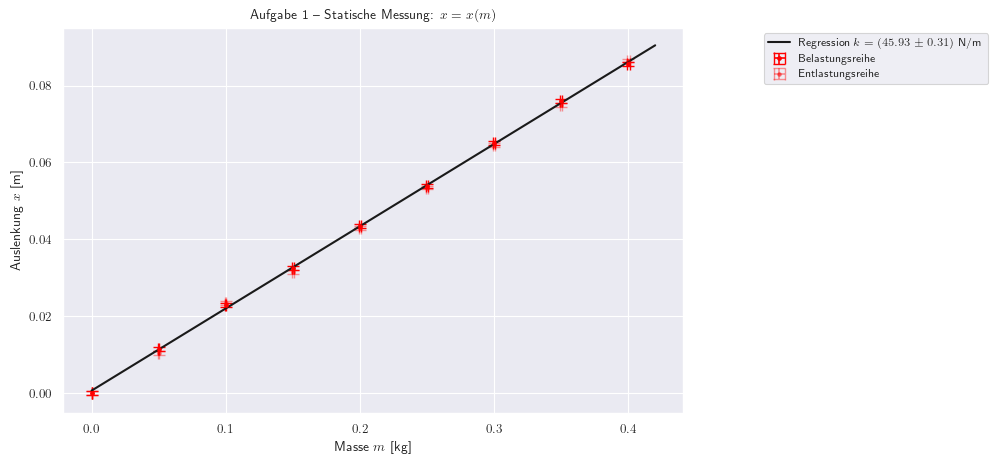

In [ ]:
# ── Plot: x = x(m) ───────────────────────────────────────────────
# x-Achse: Masse m [g], y-Achse: Auslenkung x [cm]
m_fit  = np.linspace(0, 400 * 1.05 * 1e-3, 200)
x_fit = (model_reg.intercept + model_reg.slope * m_fit)

fig, ax = plt.subplots(figsize=(8, 5))

# Ausgleichsgerade (Regression) für Belastungsreihe
ax.plot(
    m_fit, x_fit,
    'k-', lw=1.5,
    label=f'Regression  $k = ({k_reg:.2f} \\pm {dk_reg:.2f})$ N/m'
)

# Belastungsreihe
ax.errorbar(
    m_kg , x_laden_m ,
    yerr=u_x, xerr=u_m,
    fmt='.', color='red', capsize=4,
    label='Belastungsreihe'
)
# Entlastungsreihe
ax.errorbar(
    m_1_kg , x_entladen_m ,
    yerr=u_x, xerr=u_m,
    fmt='.', color='red', capsize=4, alpha=0.4,
    label='Entlastungsreihe'
)


ax.set_xlabel('Masse $m$ [kg]')
ax.set_ylabel('Auslenkung $x$ [m]')
ax.set_title('Aufgabe 1 – Statische Messung: $x = x(m)$')
ax.legend(
    loc='upper right',
    fontsize='small',
    bbox_to_anchor=(1.5, 1)
)
plt.show()

# ── Speichern (copy-paste snippet) ────────────────────────────────
# fig.savefig('F4_Aufgabe1.png', dpi=600, bbox_inches='tight')

### Aufgabe 2 – Dynamische Bestimmung der Federkonstante

> Die Feder wird mit 400 g belastet. 10-mal wird die Zeit für je 20 Schwingungen gemessen. Daraus wird der Mittelwert $\bar{T}$ und sein Vertrauensbereich $s_T$ (95 %, Student-t) berechnet. Die Federkonstante folgt aus Gl. (5). Die Eigenmasse der Feder ($m_F \approx 5$ g) wird als $m' = m_F/3$ berücksichtigt.

In [16]:
# ── Statistik der Periodendauer ───────────────────────────────────
T_mean, T_std, T_sem, T_vb = vertrauensbereich(T_einzeln)

print(f"  Mittelwert T̄       = {T_mean:.5f} s")
print(f"  Standardabweichung = {T_std:.5f} s")
print(f"  Vertrauensbereich  = ± {T_vb:.5f} s  (95 %, Student-t, n={len(T_einzeln)})")

# ── Effektive Masse (mit Federeigenmasse) ─────────────────────────
m_eff_dyn  = m_dyn_kg + m_feder / 3
dm_eff_dyn = np.sqrt(dm_dyn**2 + (m_feder / 3 * 0.10)**2)  # 10 % Unsicherheit mF

print(f"\n  Effektive Masse m_eff = {m_eff_dyn*1000:.1f} g")

# ── Federkonstante ────────────────────────────────────────────────
k_dyn  = k_aus_periodendauer(T_mean, m_eff_dyn)
dk_dyn = dk_dynamisch(k_dyn, T_mean, T_vb, m_eff_dyn, dm_eff_dyn)

print(f"\n  k (dynamisch) = ({k_dyn:.3f} ± {dk_dyn:.3f}) N/m")

  Mittelwert T̄       = 0.54526 s
  Standardabweichung = 0.03166 s
  Vertrauensbereich  = ± 0.01913 s  (95 %, Student-t, n=13)


NameError: name 'm_dyn_kg' is not defined

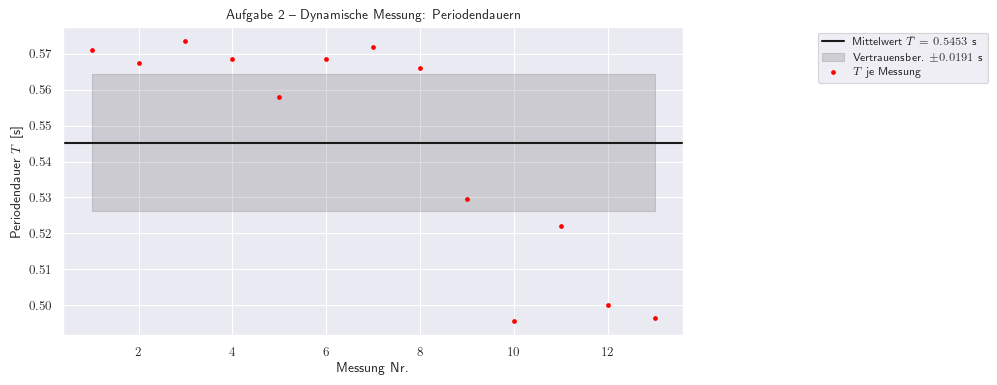

In [ ]:
# ── Plot: Periodendauern ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))

ax.errorbar(
    df2['Messung_nr'].values, T_einzeln,
    fmt='.', color='red', capsize=4,
    label='$T$ je Messung'
)
ax.axhline(
    T_mean, color='k', lw=1.5,
    label=f'Mittelwert $\\bar{{T}} = {T_mean:.4f}$ s'
)
ax.fill_between(
    df2['Messung_nr'].values,
    T_mean - T_vb, T_mean + T_vb,
    alpha=0.15, color='k',
    label=f'Vertrauensber. $\\pm {T_vb:.4f}$ s'
)

ax.set_xlabel('Messung Nr.')
ax.set_ylabel('Periodendauer $T$ [s]')
ax.set_title('Aufgabe 2 – Dynamische Messung: Periodendauern')
ax.legend(
    loc='upper right',
    fontsize='small',
    bbox_to_anchor=(1.5, 1)
)
plt.show()

# ── Speichern (copy-paste snippet) ────────────────────────────────
# fig.savefig('F4_Aufgabe2.png', dpi=600, bbox_inches='tight')

### Aufgabe 3 – Geometrische Berechnung der Federkonstante

> Aus Torsionsmodul $G$, Drahtlänge $l$, Drahtdurchmesser $d$ und Wickelradius $r$ wird $k$ nach Gl. (6) berechnet:
> $$k = \frac{\pi G d^4}{32 r^2 l}$$
> Die Unsicherheit ergibt sich durch quadratische Fehlerfortpflanzung.

In [ ]:
k_geo  = k_geometrisch(G_Pa, d_m, r_m, l_m)
dk_geo = dk_geometrisch(k_geo, G_Pa, dG_Pa, d_m, dd_m, r_m, dr_m, l_m, dl_m)

beitrag_G = (dG_Pa / G_Pa)**2
beitrag_d = (4 * dd_m / d_m)**2
beitrag_r = (2 * dr_m / r_m)**2
beitrag_l = (dl_m / l_m)**2

print(f"  k (geometrisch) = ({k_geo:.3f} ± {dk_geo:.3f}) N/m")
print(f"  Gesamtunsicherheit: {dk_geo/k_geo*100:.1f} %")
print(f"\n  Relative Unsicherheitsbeiträge:")
print(f"    G : {np.sqrt(beitrag_G)*100:.2f} %")
print(f"    d : {np.sqrt(beitrag_d)*100:.2f} %  ← dominierend (d⁴)")
print(f"    r : {np.sqrt(beitrag_r)*100:.2f} %")
print(f"    l : {np.sqrt(beitrag_l)*100:.2f} %")

  k (geometrisch) = (45.824 ± 4.395) N/m
  Gesamtunsicherheit: 9.6 %

  Relative Unsicherheitsbeiträge:
    G : 8.64 %
    d : 1.49 %  ← dominierend (d⁴)
    r : 3.81 %
    l : 0.76 %


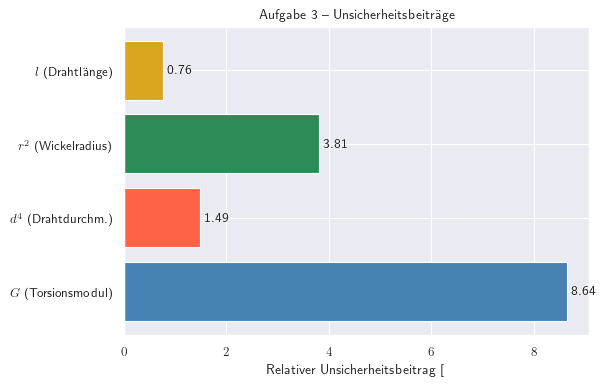

In [ ]:
# ── Plot: Relative Unsicherheitsbeiträge ─────────────────────────
fig, ax = plt.subplots(figsize=(6, 4))

bar_labels = ['$G$ (Torsionsmodul)', '$d^4$ (Drahtdurchm.)', '$r^2$ (Wickelradius)', '$l$ (Drahtlänge)']
beitr      = np.sqrt([beitrag_G, beitrag_d, beitrag_r, beitrag_l]) * 100
bars       = ax.barh(bar_labels, beitr,
                     color=['steelblue', 'tomato', 'seagreen', 'goldenrod'])
ax.bar_label(bars, fmt='%.2f %%', padding=3)
ax.set_xlabel('Relativer Unsicherheitsbeitrag [%]')
ax.set_title('Aufgabe 3 – Unsicherheitsbeiträge')
plt.show()

# ── Speichern (copy-paste snippet) ────────────────────────────────
# fig.savefig('F4_Aufgabe3.png', dpi=600, bbox_inches='tight')

### Aufgabe 4 – Abschätzung systematischer Abweichungen

> Obergrenzen der systematischen Messabweichungen bei Aufgaben 1 und 2 (statische und dynamische Methode) sind abzuschätzen. Es ist zu analysieren, welche korrigierbar sind.

In [ ]:
print("══ Statische Methode (Aufgabe 1) ══")

# Längenmessung mit Spiegelskale
x_typ_mm  = np.mean(x_mm)
dx_sys_mm = u_laenge(x_typ_mm)
print(f"  Spiegelskale: Δx_sys ≤ {dx_sys_mm:.3f} mm  (bei x ≈ {x_typ_mm:.1f} mm)")
print(f"  Auswirkung auf k:  Δk/k ≤ {dx_sys_mm/x_typ_mm*100:.2f} %")
print(f"  → Teilweise korrigierbar (Nullpunkt der Skale)")

# Masseunsicherheit
m_typ  = np.mean(m_kg)
dm_sys = np.mean(n_stuecke) * dm_stueck
print(f"\n  Massestücke: Δm_sys ≤ {dm_sys*1e3:.2f} g  (bei m ≈ {m_typ*1e3:.0f} g)")
print(f"  Auswirkung auf k:  Δk/k ≤ {dm_sys/m_typ*100:.3f} %  (vernachlässigbar)")
print(f"  → Nicht korrigierbar; geht in Messunsicherheit ein")

print("\n══ Dynamische Methode (Aufgabe 2) ══")

# Reaktionszeit der Stoppuhr
dt_reak  = 0.15    # s (typische Reaktionszeit)
n_schw   = df2['Schwingungen_n'].values[0]
dt_sys_T = dt_reak / n_schw
dk_sys_T = k_dyn * 2 * dt_sys_T / T_mean
print(f"  Reaktionszeit: Δt ≈ {dt_reak:.2f} s → ΔT_sys ≈ {dt_sys_T:.5f} s/Periode")
print(f"  Auswirkung auf k:  Δk_sys ≈ {dk_sys_T:.3f} N/m")
print(f"  → Kürzt sich bei symmetrischem Start/Stopp-Fehler teilweise heraus")

# Korrektur Federeigenmasse
k_ohne = k_aus_periodendauer(T_mean, m_dyn_kg)
print(f"\n  Ohne Federeigenmasse: k = {k_ohne:.3f} N/m")
print(f"  Mit Korrektur m'=mF/3: k = {k_dyn:.3f} N/m")
print(f"  Korrektur: {abs(k_dyn - k_ohne):.3f} N/m → korrigierbar!")

print(f"\n  Seitliche Schwingungsanteile: erhöhen T → k wird unterschätzt")
print(f"  → Nicht korrigierbar; vermeidbar durch sorgfältige Auslenkung")
print(f"\n  Reibung: verlängert T leicht → k leicht unterschätzt")
print(f"  → Nicht korrigierbar; geht in Messunsicherheit ein")

══ Statische Methode (Aufgabe 1) ══
  Spiegelskale: Δx_sys ≤ 0.970 mm  (bei x ≈ 1539.7 mm)
  Auswirkung auf k:  Δk/k ≤ 0.06 %
  → Teilweise korrigierbar (Nullpunkt der Skale)

  Massestücke: Δm_sys ≤ 0.50 g  (bei m ≈ 200000 g)
  Auswirkung auf k:  Δk/k ≤ 0.000 %  (vernachlässigbar)
  → Nicht korrigierbar; geht in Messunsicherheit ein

══ Dynamische Methode (Aufgabe 2) ══
  Reaktionszeit: Δt ≈ 0.15 s → ΔT_sys ≈ 0.00789 s/Periode
  Auswirkung auf k:  Δk_sys ≈ 1.544 N/m
  → Kürzt sich bei symmetrischem Start/Stopp-Fehler teilweise heraus

  Ohne Federeigenmasse: k = 53.114 N/m
  Mit Korrektur m'=mF/3: k = 53.335 N/m
  Korrektur: 0.221 N/m → korrigierbar!

  Seitliche Schwingungsanteile: erhöhen T → k wird unterschätzt
  → Nicht korrigierbar; vermeidbar durch sorgfältige Auslenkung

  Reibung: verlängert T leicht → k leicht unterschätzt
  → Nicht korrigierbar; geht in Messunsicherheit ein


### Aufgabe 5 – Vergleich aller Methoden und gewichteter Mittelwert

> Die Ergebnisse aller drei Aufgaben (1a Steigungsdreieck, 1b Regression, 2 dynamisch, 3 geometrisch) werden tabellarisch dargestellt und verglichen. Ein gewichteter Mittelwert wird ermittelt.

In [ ]:
# ── Ergebnistabelle ───────────────────────────────────────────────
methoden = [
    ('Statisch – Steigungsdreieck', k_sd,  dk_sd),
    ('Statisch – Regression',       k_reg, dk_reg),
    ('Dynamisch',                   k_dyn, dk_dyn),
    ('Geometrisch',                 k_geo, dk_geo),
]

df_ergebnisse = pd.DataFrame(
    methoden,
    columns=['Methode', 'k [N/m]', 'Δk [N/m]']
)
df_ergebnisse['Δk/k [%]'] = (df_ergebnisse['Δk [N/m]'] / df_ergebnisse['k [N/m]'] * 100).round(2)
display(df_ergebnisse)

# ── Gewichteter Mittelwert ────────────────────────────────────────
k_vals       = [row[1] for row in methoden]
dk_vals      = [row[2] for row in methoden]
k_gm, dk_gm = gewichteter_mittelwert(k_vals, dk_vals)

print(f"\n  Gewichteter Mittelwert: k = ({k_gm:.3f} ± {dk_gm:.3f}) N/m")
print("\n  Hinweis: Der gewichtete Mittelwert ist nur sinnvoll, wenn alle")
print("  Methoden dieselbe Größe unabhängig voneinander messen und keine")
print("  gemeinsamen systematischen Fehler vorliegen.")

,Methode,k [N/m],Δk [N/m],Δk/k [%]
0,Statisch – Steigungsdreieck,235512.000000,11775.600000,5.00
1,Statisch – Regression,235512.000000,735834.807195,312.44
2,Dynamisch,53.335113,3.744745,7.02
3,Geometrisch,45.823513,4.395011,9.59



  Gewichteter Mittelwert: k = (50.189 ± 2.850) N/m

  Hinweis: Der gewichtete Mittelwert ist nur sinnvoll, wenn alle
  Methoden dieselbe Größe unabhängig voneinander messen und keine
  gemeinsamen systematischen Fehler vorliegen.


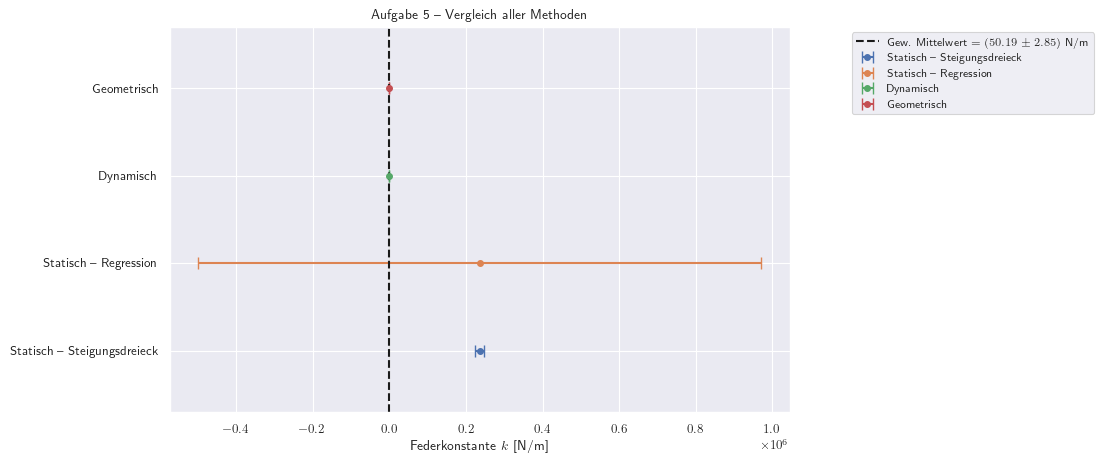

In [ ]:
# ── Vergleichsgrafik ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))

for i, (name, k, dk) in enumerate(methoden):
    ax.errorbar(
        k, i, xerr=dk,
        fmt='.',  capsize=4,
        markersize=8, lw=1.5, label=name
    )

ax.axvline(
    k_gm, color='k', lw=1.5, linestyle='--',
    label=f'Gew. Mittelwert $= ({k_gm:.2f} \\pm {dk_gm:.2f})$ N/m'
)
ax.fill_betweenx(
    [-0.5, len(methoden) - 0.5],
    k_gm - dk_gm, k_gm + dk_gm,
    alpha=0.12, color='k'
)

ax.set_yticks(range(len(methoden)))
ax.set_yticklabels([row[0] for row in methoden])
ax.set_xlabel('Federkonstante $k$ [N/m]')
ax.set_title('Aufgabe 5 – Vergleich aller Methoden')
ax.legend(
    loc='upper right',
    fontsize='small',
    bbox_to_anchor=(1.5, 1)
)
plt.show()

# ── Speichern (copy-paste snippet) ────────────────────────────────
# fig.savefig('F4_Aufgabe5.png', dpi=600, bbox_inches='tight')